# Mietpreisvorhersage Schweiz – Modellierungs-Notebook

> ➡️ *Dieses Notebook entwickelt ein Machine-Learning-Modell zur Vorhersage von Wohnungs-Kaltmieten in der Schweiz. Die Eingabefeatures kombinieren wohnungsspezifische Attribute (Fläche, Zimmer) mit standortbezogenen Variablen (Koordinaten, ÖV-Anbindung, Bevölkerungsdichte, Solarpotenzial).*

**Roter Faden des Notebooks:**

1. **Daten laden & aufbereiten** – CSV einlesen, Spalten sinnvoll umbenennen, konsistente Reihenfolge herstellen.
2. **Explorative Datenanalyse** – Verteilungen, Korrelationen und Skewness/Kurtosis untersuchen, um Datenqualität und mögliche Transformationen zu verstehen.
3. **Feature-Auswahl & Skalierung** – stark korrelierte oder wenig informative Features entfernen und alle verbleibenden Features standardisieren.
4. **Train-Eval-Split** – konsistenter Split (`random_state=2019`), der von allen folgenden Modellen genutzt wird.
5. **Baseline & Benchmarking** – einfache Referenzmodelle (DummyRegressor, LinearRegression, RandomForest), gegen die sich die komplexeren Modelle messen müssen.
6. **Optimierte Boosting-Modelle** – XGBoost und LightGBM mit zuvor durch Tuning ermittelten Hyperparametern.
7. **Modellvergleich** – alle fünf Modelle in einer gemeinsamen Tabelle und in Vergleichs-Plots (MedAE, R², Cross-Validation).
8. **Test-Predictions** – finale Vorhersage auf dem Hold-out-Test-Set mit den besten Modellen.

**Warum dieser Aufbau?** Die Benchmarks vor den getunten Modellen sorgen dafür, dass jede gemeldete Verbesserung *messbar relativ* zu einer trivialen Lösung ist. Nur so können wir am Ende ehrlich sagen, ob sich der Aufwand für XGBoost/LightGBM gelohnt hat.

# Inhaltsverzeichnis

1. **Setup & Bibliotheken**
2. **Daten laden und aufbereiten**
    - 2.1 Spalten umbenennen
    - 2.2 Spalten sortieren
3. **Explorative Datenanalyse (EDA)**
    - 3.1 Fehlende Werte
    - 3.2 Train/Test zusammenführen
    - 3.3 Univariate Analyse
    - 3.4 Bivariate Analyse
    - 3.5 Korrelations-Heatmap
4. **Feature-Diagnostik**
    - 4.1 Feature-Namen & deskriptive Statistik
    - 4.2 Verteilungsvergleich Train/Test
    - 4.3 Skewness & Kurtosis
    - 4.4 Train/Test rekonstruieren
    - 4.5 Feature Importance: XGBoost
    - 4.6 Feature Importance: LightGBM
    - 4.7 Feature Importance: CatBoost
    - 4.8 Pearson-Korrelation
5. **Datenvorbereitung für die Modellierung**
    - 5.1 Feature-Matrix und Zielvariable definieren
    - 5.2 Preprocessing-Transformatoren importieren
    - 5.3 Features standardisieren
    - 5.4 Train-Eval-Split
    - 5.5 Zielverteilung analysieren
    - 5.6 Zielvariable Boxplot
6. **Baseline & Benchmarking**
7. **Optimierte Boosting-Modelle**
    - 7.1 XGBoost Hyperparameter
    - 7.2 LightGBM Hyperparameter
    - 7.3 Modelle trainieren
    - 7.4 Cross-Validation & Eval-Metriken
8. **Modellvergleich (alle 5 Modelle)**
    - 8.1 Vergleichstabelle
    - 8.2 Visualisierung MedAE
    - 8.3 Visualisierung R²-Score
    - 8.4 Visualisierung Cross-Validation
    - 8.5 Zwischenfazit der Modellbewertung
9. **Test-Predictions**
    - 9.1 Test-Datensatz vorbereiten
    - 9.2 Trainings-Feature-Matrix vorbereiten
    - 9.3 Skalierung Train + Test
    - 9.4 Skalierte Test-Features finalisieren

# 1. Setup & Bibliotheken


> ℹ️ *We install now all the libraries here in the venv.*

In [1]:
#The following Python packages are installed into the active virtual environment:
!pip install optuna
!pip install catboost
!pip install lightgbm
!pip install missingno optuna xgboost catboost lightgbm eli5


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


> ℹ️ *First, we import the necessary Python libraries.*


In [102]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import median_absolute_error
from sklearn.metrics import mean_squared_log_error
from sklearn.metrics import r2_score
from scipy import stats
import pandas as pd
import numpy as np
import base64,os,random,gc
import seaborn as sns
import matplotlib.pyplot as plt
import missingno as msno


import matplotlib.pyplot as plotter
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import optuna
import xgboost as xgb
from xgboost import XGBRegressor
import catboost
from catboost import CatBoostRegressor
import lightgbm as lgbm
from lightgbm import LGBMRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn import datasets
optuna.logging.set_verbosity(optuna.logging.WARNING)
from lightgbm import *
pd.set_option("display.max_columns", None)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
import eli5
from eli5.sklearn import PermutationImportance

import warnings
warnings.filterwarnings('ignore')

# 2. Daten laden und aufbereiten

> ➡️ *Here, we import data from a csv file, with pandas.*



In [103]:
train = pd.read_csv("../external-sources/output_csv/model.csv")
train, test = train_test_split(train, test_size=0.2, random_state=42)
train=train.reset_index(drop=True)
test=test.reset_index(drop=True)
display(train.head())
display(test.head())

,area_sqm,rooms,price_cold,population,oev_score,solar_class,elevation_m,lv95_east,lv95_north,gbauj,ganzwhg,garea
0,109,3,1690,67,342.0,3.0,457.5,2755331.00,1221328.750,2014,10,446.0
1,121,2,3100,33,1335.0,2.0,513.1,2683559.25,1240013.875,1986,11,485.0
2,115,4,2605,183,14054.0,4.0,392.4,2667247.50,1255916.125,2011,8,363.0
3,55,2,1250,25,9693.0,1.0,329.3,2622505.25,1259121.875,1750,8,381.0
4,39,1,790,138,7732.0,2.0,670.6,2746813.50,1254518.750,1987,13,331.0


,area_sqm,rooms,price_cold,population,oev_score,solar_class,elevation_m,lv95_east,lv95_north,gbauj,ganzwhg,garea
0,57,2,1890,186,10892.0,3.0,556.9,2539103.75,1152548.250,1933,20,420.0
1,48,2,1440,58,73.0,3.0,517.0,2655301.50,1222483.375,1969,5,409.0
2,70,2,1500,29,126.0,4.0,1356.0,2604730.00,1129117.875,1969,16,297.0
3,94,3,1670,144,3537.0,4.0,299.5,2638795.25,1266197.000,2005,9,267.0
4,84,3,1630,93,4172.0,4.0,545.0,2613913.50,1210679.250,2005,8,292.0


## 2.1 Spalten umbenennen

> ➡️ *Now we rename the columns to more suitable names and sort them accordingly.*

In [104]:
new_names = {
    "area_sqm": "area",
    "rooms": "rooms",
    "price_cold": "price",
    "population": "population",
    "oev_score": "oev",
    "solar_class": "solar",
    "elevation_m": "elevation",
    "lv95_east": "east",
    "lv95_north": "north",
    "gbauj": "year_built",
    "ganzwhg": "apartments",
    "garea": "land_area",
}

train = train.rename(columns=new_names)
test = test.rename(columns=new_names)

> ➡️ *After rename:*

In [105]:
display(train.tail())
display(test.tail())

,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area
3623,68,3,1661,32,1058.0,4.0,505.5,2679710.25,1251235.875,1954,6,260.0
3624,97,4,1870,133,4415.0,4.0,533.0,2614712.25,1212489.750,1973,15,351.0
3625,31,1,835,177,6423.0,1.0,667.2,2744574.25,1253861.000,1918,12,158.0
3626,111,4,1770,110,930.0,3.0,403.4,2748842.50,1264033.375,1974,36,441.0
3627,86,3,1400,56,658.0,2.0,485.6,2561968.75,1193881.125,2009,6,240.0


,area,rooms,price,population,oev,solar,elevation,east,north,year_built,apartments,land_area
903,54,2,1200,37,297.0,4.0,342.9,2697976.50,1122567.375,1972,2,105.0
904,80,2,2340,79,2017.0,3.0,440.5,2681588.00,1253222.125,1981,6,247.0
905,113,3,1800,17,2174.0,1.0,524.9,2605452.50,1210915.875,1755,8,484.0
906,90,3,1840,81,5234.0,4.0,454.4,2609938.75,1224044.250,2014,8,312.0
907,285,8,3800,41,4362.0,1.0,424.7,2559432.50,1143123.250,1890,1,59.0


## 2.2 Spalten sortieren

> ➡️ *Now we sort it.*

In [106]:
fixed_order = [
    "east",
    "north",
    "elevation",
    "area",
    "rooms",
    "year_built",
    "apartments",
    "land_area",
    "population",
    "oev",
    "solar",
    "price"
]
train = train[fixed_order]
test = test[fixed_order]

> ➡️ *Result after sorting.*

In [107]:
display(train.tail())
display(test.tail())

,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
3623,2679710.25,1251235.875,505.5,68,3,1954,6,260.0,32,1058.0,4.0,1661
3624,2614712.25,1212489.750,533.0,97,4,1973,15,351.0,133,4415.0,4.0,1870
3625,2744574.25,1253861.000,667.2,31,1,1918,12,158.0,177,6423.0,1.0,835
3626,2748842.50,1264033.375,403.4,111,4,1974,36,441.0,110,930.0,3.0,1770
3627,2561968.75,1193881.125,485.6,86,3,2009,6,240.0,56,658.0,2.0,1400


,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
903,2697976.50,1122567.375,342.9,54,2,1972,2,105.0,37,297.0,4.0,1200
904,2681588.00,1253222.125,440.5,80,2,1981,6,247.0,79,2017.0,3.0,2340
905,2605452.50,1210915.875,524.9,113,3,1755,8,484.0,17,2174.0,1.0,1800
906,2609938.75,1224044.250,454.4,90,3,2014,8,312.0,81,5234.0,4.0,1840
907,2559432.50,1143123.250,424.7,285,8,1890,1,59.0,41,4362.0,1.0,3800


# 3. Explorative Datenanalyse (EDA)

## 3.1 Fehlende Werte

> ➡️ *Here, we inspect missing values in both the training and testing datasets and visualize their distribution using heatmaps.*


train


east          0
north         0
elevation     0
area          0
rooms         0
year_built    0
apartments    0
land_area     0
population    0
oev           0
solar         0
price         0
dtype: int64

test


east          0
north         0
elevation     0
area          0
rooms         0
year_built    0
apartments    0
land_area     0
population    0
oev           0
solar         0
price         0
dtype: int64

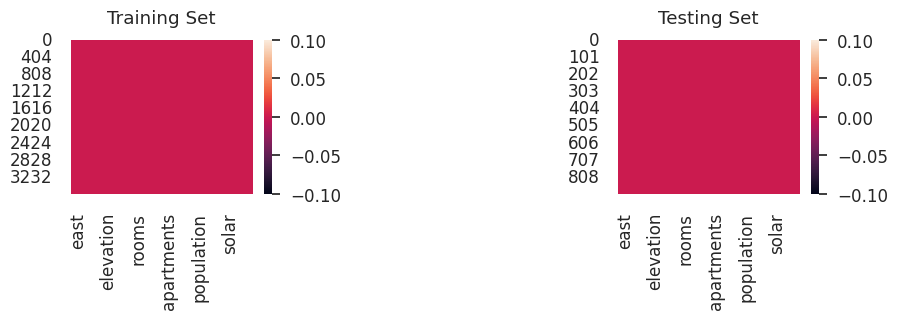

In [108]:
print('train')
display(train.isnull().sum())
print('test')
display(test.isnull().sum())

plt.figure(figsize = (10, 2))

plt.subplot(1, 3, 1)
plt.title("Training Set")
sns.heatmap(train.isnull())

plt.subplot(1, 3, 3)
plt.title("Testing Set")
sns.heatmap(test.isnull())
plt.show()

> ➡️ *Here, we visualize missing values in the training dataset using the missingno matrix plot.*

<Axes: >

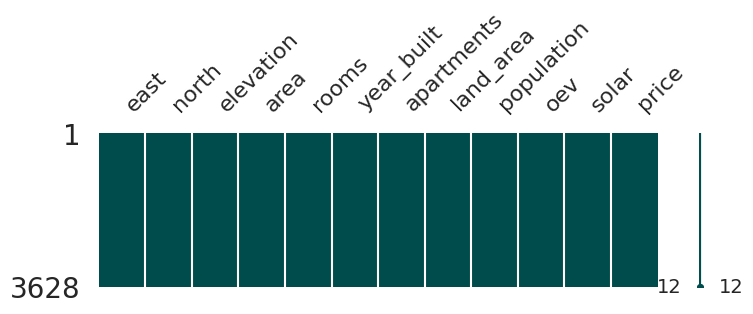

In [109]:
msno.matrix(df=train, figsize=(8,2), color=(0,.3,.3))

<Axes: >

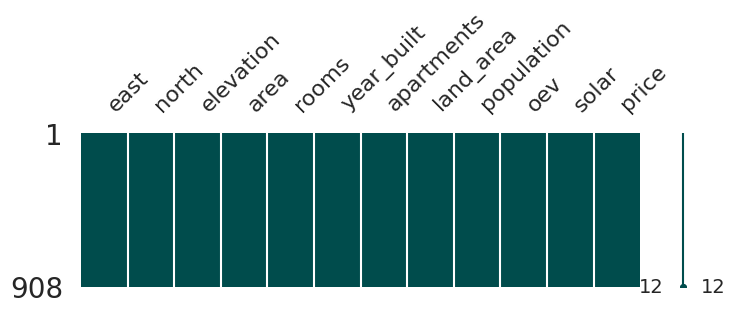

In [110]:
msno.matrix(df=test, figsize=(8,2), color=(0,.3,.3))


In [111]:
print('train')
display(train.info())
print('test')
display(test.info())

train
<class 'pandas.DataFrame'>
RangeIndex: 3628 entries, 0 to 3627
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   east        3628 non-null   float64
 1   north       3628 non-null   float64
 2   elevation   3628 non-null   float64
 3   area        3628 non-null   int64  
 4   rooms       3628 non-null   int64  
 5   year_built  3628 non-null   int64  
 6   apartments  3628 non-null   int64  
 7   land_area   3628 non-null   float64
 8   population  3628 non-null   int64  
 9   oev         3628 non-null   float64
 10  solar       3628 non-null   float64
 11  price       3628 non-null   int64  
dtypes: float64(6), int64(6)
memory usage: 340.3 KB


None

test
<class 'pandas.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   east        908 non-null    float64
 1   north       908 non-null    float64
 2   elevation   908 non-null    float64
 3   area        908 non-null    int64  
 4   rooms       908 non-null    int64  
 5   year_built  908 non-null    int64  
 6   apartments  908 non-null    int64  
 7   land_area   908 non-null    float64
 8   population  908 non-null    int64  
 9   oev         908 non-null    float64
 10  solar       908 non-null    float64
 11  price       908 non-null    int64  
dtypes: float64(6), int64(6)
memory usage: 85.3 KB


None

## 3.2 Train/Test zusammenführen

> ➡️ *Here, we merge the training and test datasets into a single DataFrame to perform consistent preprocessing and feature engineering across both sets.*


In [112]:
df = pd.concat([train, test], ignore_index=True)
df

,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
0,2755331.00,1221328.750,457.5,109,3,2014,10,446.0,67,342.0,3.0,1690
1,2683559.25,1240013.875,513.1,121,2,1986,11,485.0,33,1335.0,2.0,3100
2,2667247.50,1255916.125,392.4,115,4,2011,8,363.0,183,14054.0,4.0,2605
3,2622505.25,1259121.875,329.3,55,2,1750,8,381.0,25,9693.0,1.0,1250
4,2746813.50,1254518.750,670.6,39,1,1987,13,331.0,138,7732.0,2.0,790
...,...,...,...,...,...,...,...,...,...,...,...,...
4531,2697976.50,1122567.375,342.9,54,2,1972,2,105.0,37,297.0,4.0,1200
4532,2681588.00,1253222.125,440.5,80,2,1981,6,247.0,79,2017.0,3.0,2340
4533,2605452.50,1210915.875,524.9,113,3,1755,8,484.0,17,2174.0,1.0,1800
4534,2609938.75,1224044.250,454.4,90,3,2014,8,312.0,81,5234.0,4.0,1840


## 3.3 Univariate Analyse

In [113]:
import matplotlib.pyplot as plt
import seaborn as sns

# Einheitliches Theme
plt.style.use('seaborn-v0_8')

# Globale rcParams
plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.2,
    'axes.grid': True,
    'grid.color': '#DDDDDD',
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans'],
    'legend.frameon': False,
    'axes.titlepad': 12,
})

# Einheitliche Farbpalette
sns.set_palette("crest")


In [114]:
COLOR_PRIMARY = "crest"     # Blau


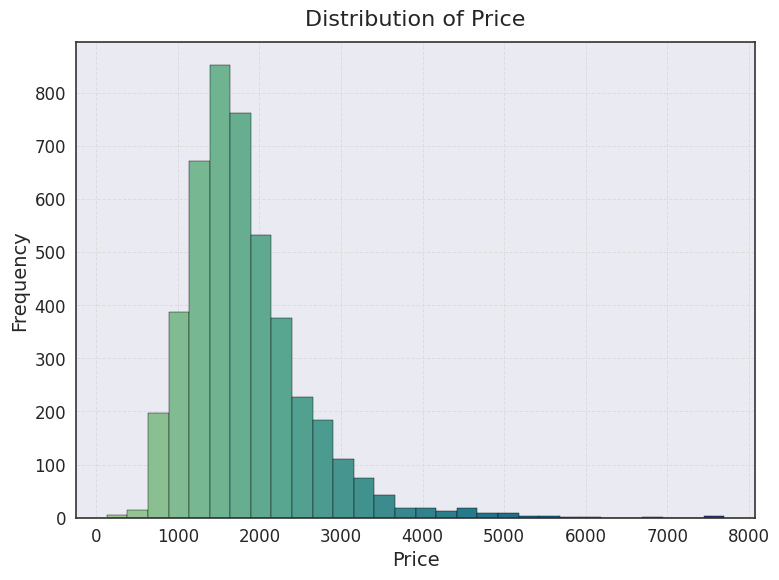

In [115]:
import numpy as np

values = df['price'].dropna()
counts, bins = np.histogram(values, bins=30)

colors = sns.color_palette(COLOR_PRIMARY, len(counts))

plt.figure(figsize=(8, 6))
for i in range(len(counts)):
    plt.bar(
        bins[i],
        counts[i],
        width=bins[i+1] - bins[i],
        color=colors[i],
        edgecolor="black",
        align="edge"
    )

plt.title('Distribution of Price')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()


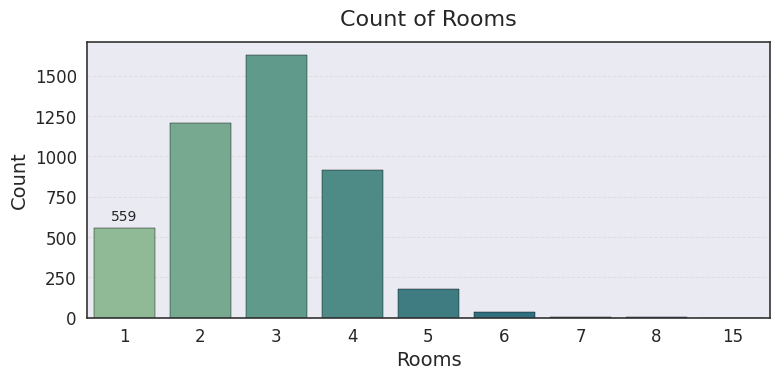

In [116]:
bedrooms_count = df['rooms'].value_counts().sort_index()

colors = sns.color_palette(COLOR_PRIMARY, len(bedrooms_count))

plt.figure(figsize=(8, 4))
ax = sns.barplot(
    x=bedrooms_count.index,
    y=bedrooms_count.values,
    palette=colors,
    edgecolor="black"
)

ax.bar_label(ax.containers[0], fontsize=10, padding=3)

plt.title('Count of Rooms')
plt.xlabel('Rooms')
plt.ylabel('Count')
plt.tight_layout()
plt.show()


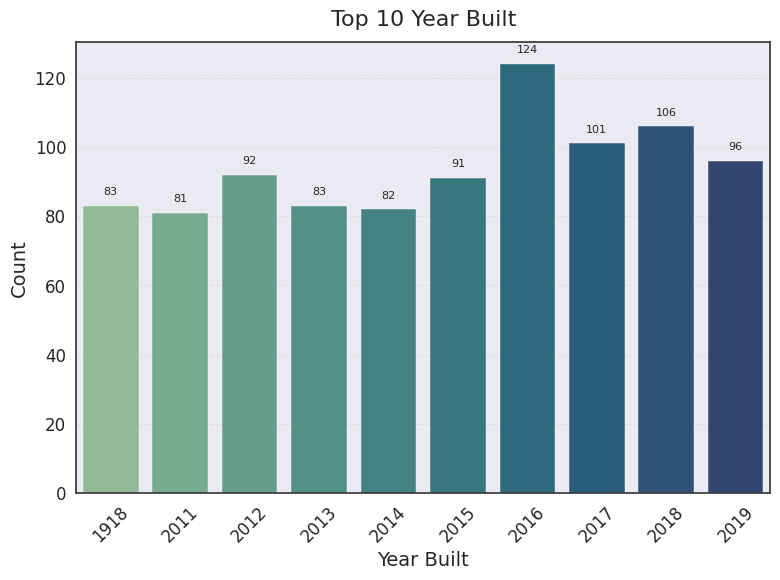

In [117]:
top_year_built = df['year_built'].value_counts().nlargest(10)

plt.figure(figsize=(8,6))
ax = sns.barplot(x=top_year_built.index, y=top_year_built.values, palette=COLOR_PRIMARY)
for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'),
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha = 'center', va = 'center',
                xytext = (0, 10),
                textcoords = 'offset points',
                fontsize=8)
plt.title('Top 10 Year Built')
plt.xlabel('Year Built')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3.4 Bivariate Analyse


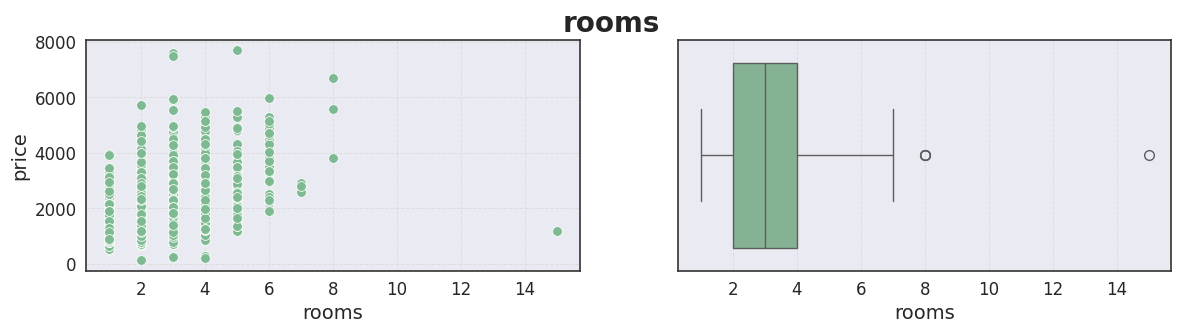

In [118]:
x = 'rooms'

fig = plt.figure(figsize=(14, 3))
sns.set_palette(COLOR_PRIMARY)
plt.suptitle(x, size=20, weight='bold')

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y='price', data=df)

plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df)

plt.show()

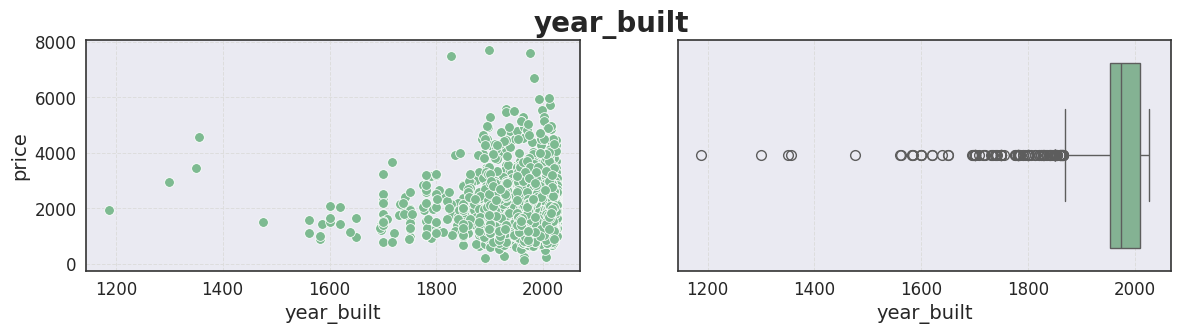

In [119]:
x = 'year_built'
sns.set_palette(COLOR_PRIMARY)

fig = plt.figure(figsize=(14, 3))
plt.suptitle(x, size=20, weight='bold')

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y='price', data=df)

plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df)

plt.show()

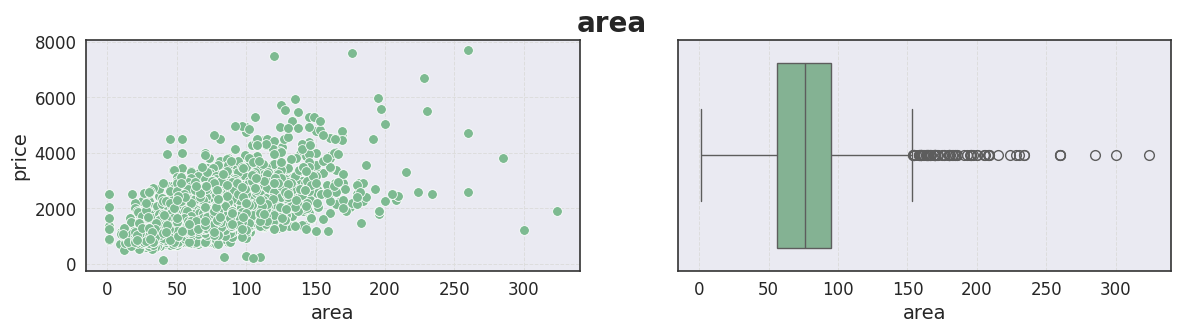

In [120]:
x = 'area'

fig = plt.figure(figsize=(14, 3))
sns.set_palette(COLOR_PRIMARY)
plt.suptitle(x, size=20, weight='bold')

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y='price', data=df)

plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df)

plt.show()

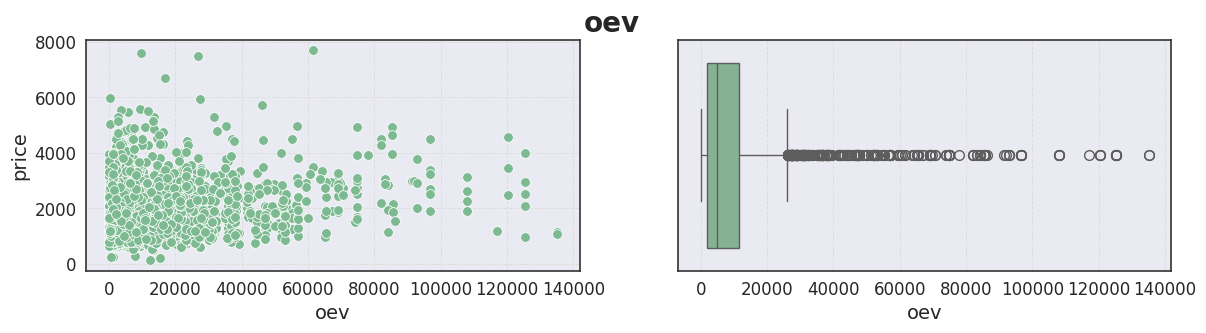

In [121]:
x = 'oev'

fig = plt.figure(figsize=(14, 3))
sns.set_palette(COLOR_PRIMARY)
plt.suptitle(x, size=20, weight='bold')

plt.subplot(1, 2, 1)
sns.scatterplot(x=x, y='price', data=df)

plt.subplot(1, 2, 2)
ax = sns.boxplot(x=x, data=df)

plt.show()

## 3.5 Korrelations-Heatmap

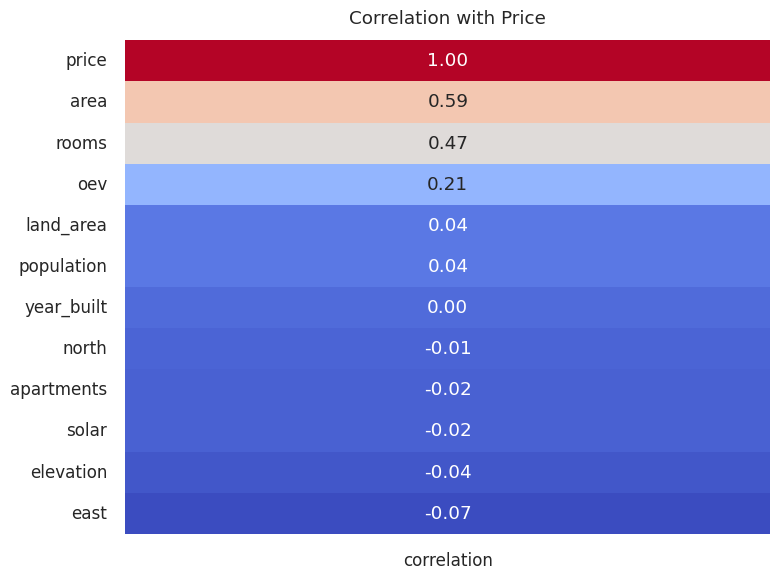

In [122]:
selected_columns = [
    "east",
    "north",
    "elevation",
    "area",
    "rooms",
    "year_built",
    "apartments",
    "land_area",
    "population",
    "oev",
    "solar",
    "price"
]

target_corr = df[selected_columns].corrwith(df["price"])

# höchste Korrelation oben
target_corr = target_corr.sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.set(font_scale=1.1)
sns.set_style("white")
sns.set_palette("PuBuGn_d")

sns.heatmap(
    target_corr.to_frame(name="correlation"),
    cmap="coolwarm",      # <-- Farbanpassung
    annot=True,
    fmt=".2f",
    cbar=False
)

plt.title("Correlation with Price")
plt.tight_layout()
plt.show()


# 4. Feature-Diagnostik

## 4.1 Feature-Namen & deskriptive Statistik

> ➡️ *Here, we extract the list of feature column names from the training dataset by removing the target variable to ensure consistent alignment with the model inputs.*


In [123]:
train_feature = train.columns.drop('price').tolist()
train_feature

['east',
 'north',
 'elevation',
 'area',
 'rooms',
 'year_built',
 'apartments',
 'land_area',
 'population',
 'oev',
 'solar']

> ➡️ *Here, we generate a descriptive statistics table for the training features and enhance it with visual styling to highlight mean values, standard deviations, and median distributions.*

In [178]:
train[train_feature].describe().T\
        .style.bar(subset=['mean'], color=px.colors.qualitative.G10[0])\
        .background_gradient(subset=['std'], cmap='BuPu')\
        .background_gradient(subset=['50%'], cmap='Reds')

,count,mean,std,min,25%,50%,75%,max
east,4535.000000,2641016.751378,69268.006730,2494493.750000,2596575.375000,2645845.500000,2690948.625000,2818550.000000
north,4535.000000,1218735.001902,52049.353680,1076962.000000,1178861.687500,1244677.375000,1258623.625000,1286728.500000
elevation,4535.000000,462.415458,158.834182,197.700000,391.500000,435.600000,517.000000,1570.700000
area,4535.000000,77.478280,31.958328,1.000000,56.000000,76.000000,95.000000,324.000000
rooms,4535.000000,2.801103,1.100246,1.000000,2.000000,3.000000,4.000000,15.000000
year_built,4535.000000,1968.942227,55.635152,1187.000000,1953.000000,1974.000000,2010.000000,2026.000000
apartments,4535.000000,15.735612,21.711080,1.000000,6.000000,10.000000,17.000000,317.000000
land_area,4535.000000,405.133407,536.871531,27.000000,195.000000,279.000000,420.000000,13020.000000
population,4535.000000,109.114884,82.580838,3.000000,49.000000,90.000000,144.000000,602.000000
oev,4535.000000,9987.309372,14961.723880,0.000000,1800.000000,4915.000000,11549.000000,135157.000000


## 4.2 Verteilungsvergleich Train/Test

> ➡️ *Here, we compare the feature distributions between the training and test datasets by plotting side‑by‑side histograms for each variable.*


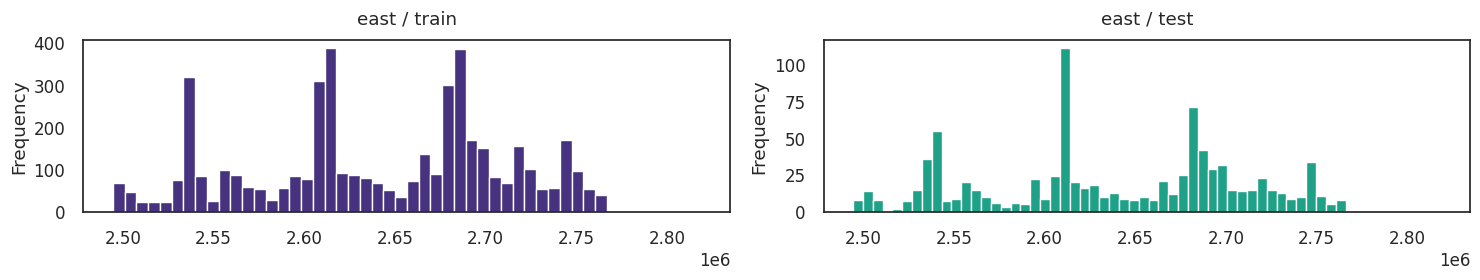

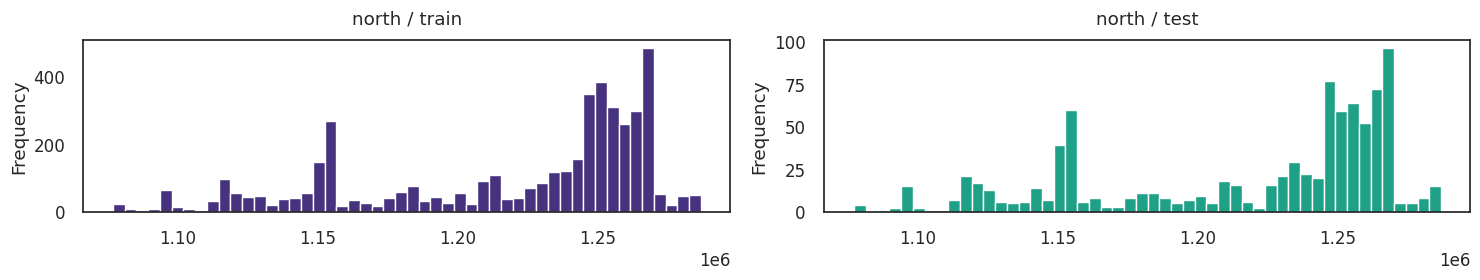

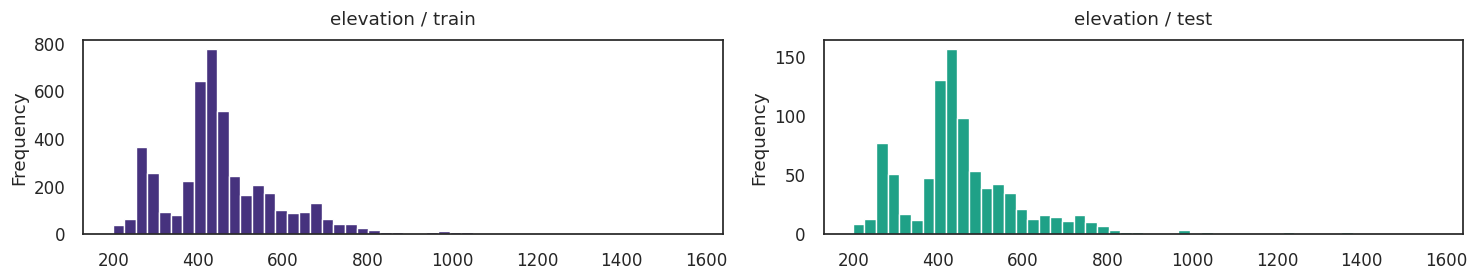

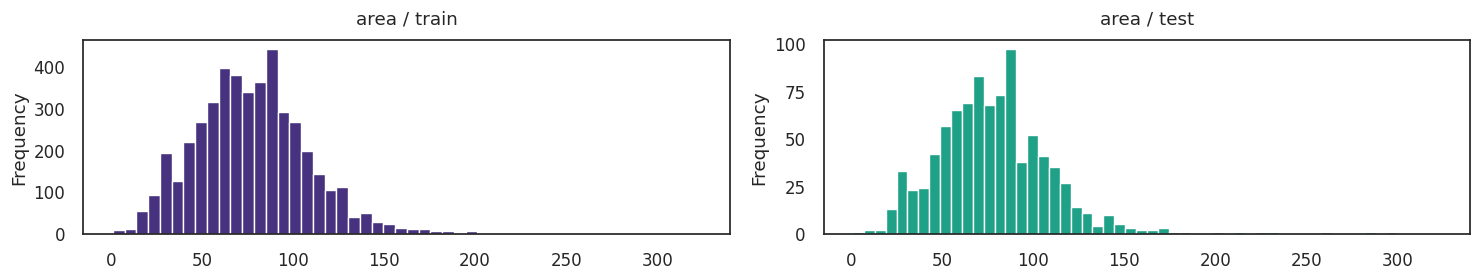

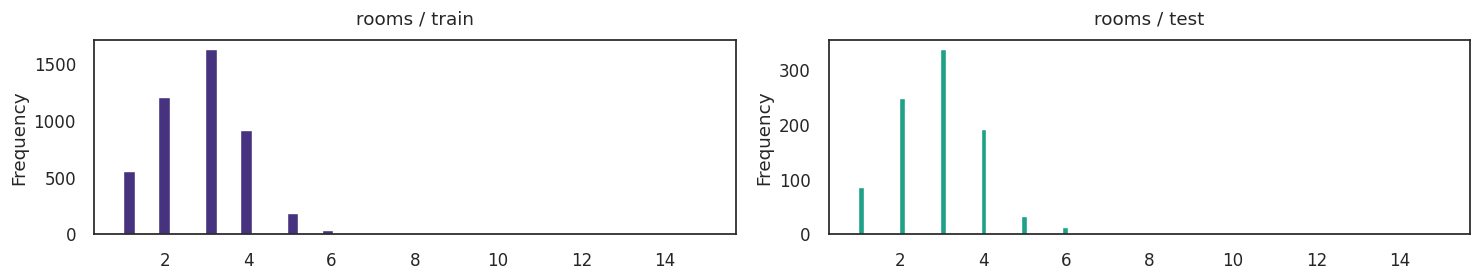

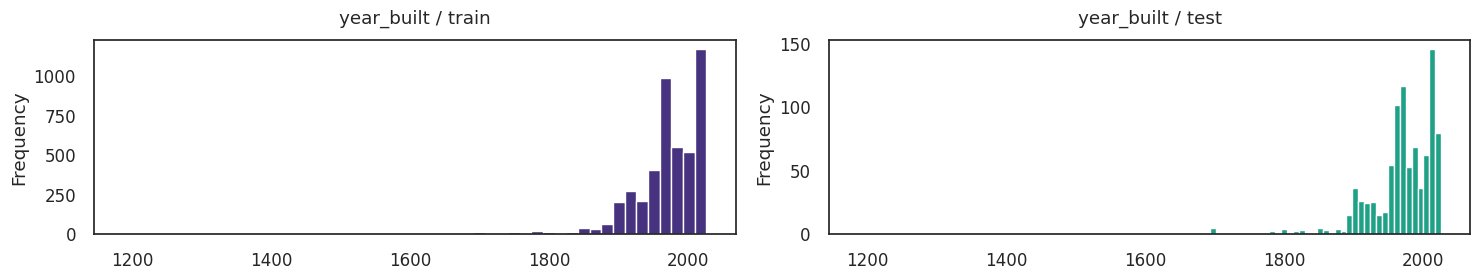

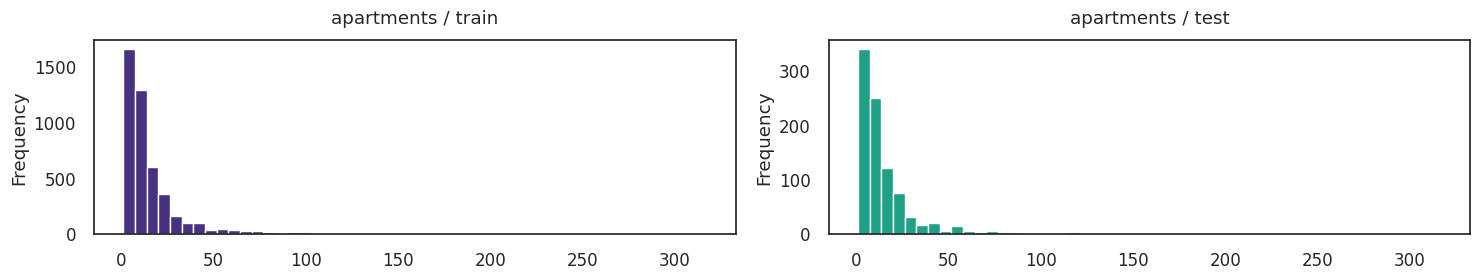

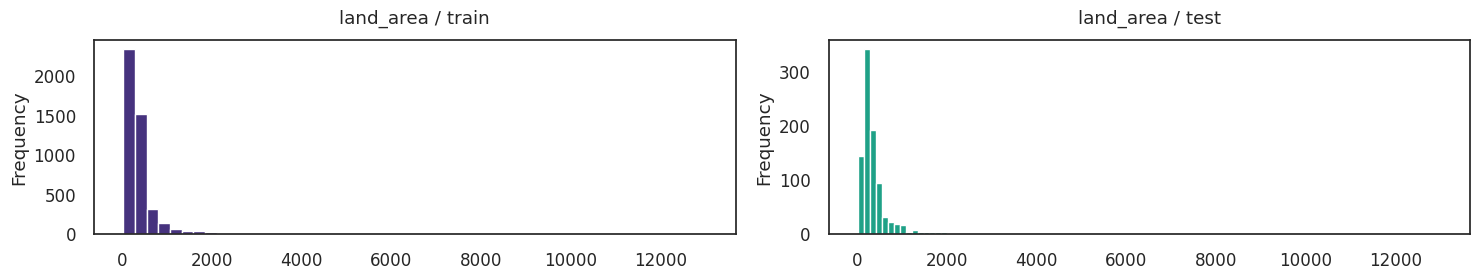

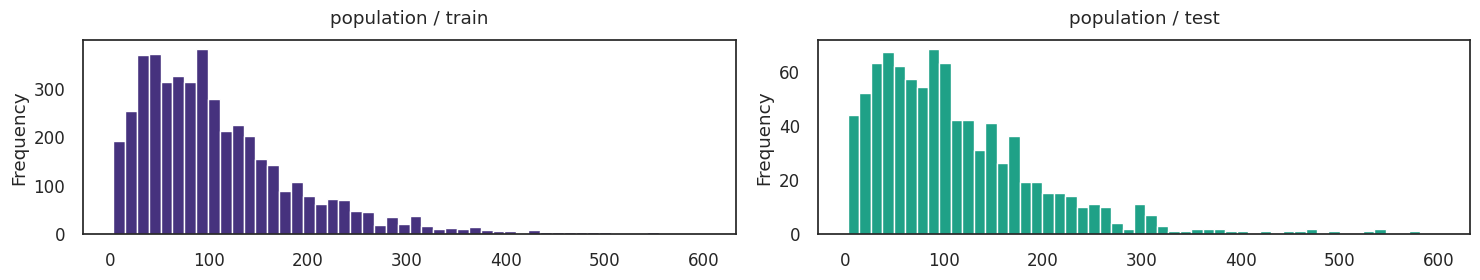

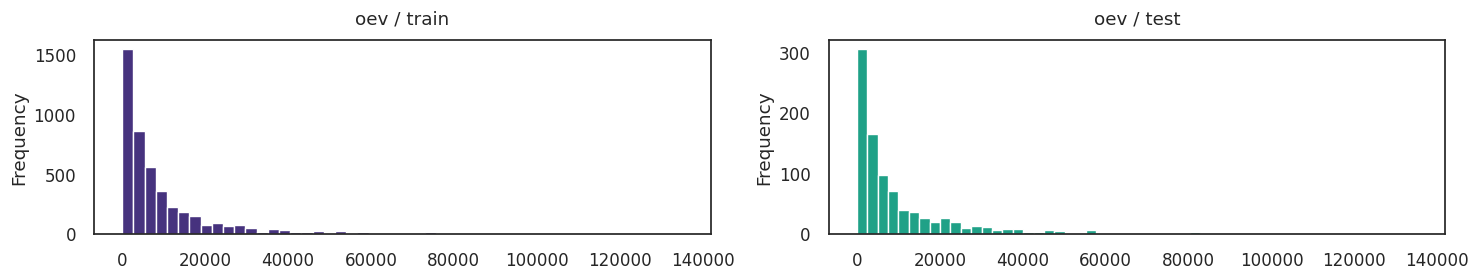

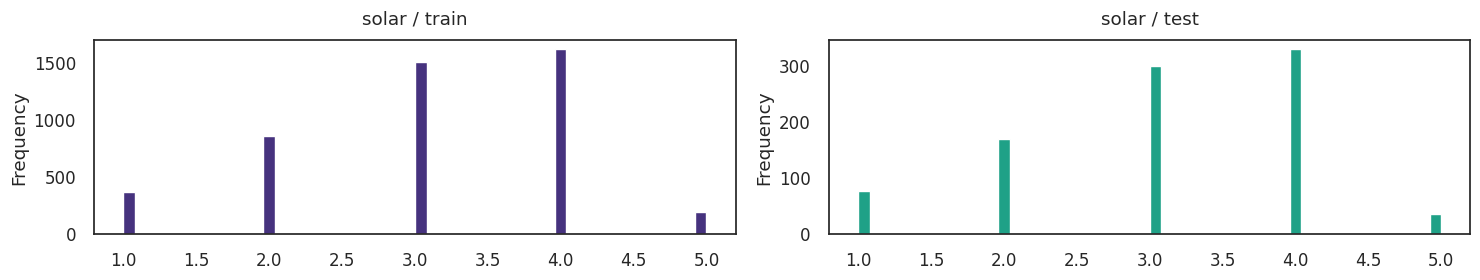

In [172]:
for feat in train_feature:
    plt.figure(figsize=(15, 3))

    # viridis-Farben hartcodiert aus der Palette
    color_train = sns.color_palette("viridis")[0]   # dunkel
    color_test  = sns.color_palette("viridis")[3]   # mittel-hell

    ax1 = plt.subplot(1, 2, 1)
    train[feat].plot(
        kind='hist',
        bins=50,
        color=color_train
    )
    plt.title(f"{feat} / train")

    ax2 = plt.subplot(1, 2, 2, sharex=ax1)
    test[feat].plot(
        kind='hist',
        bins=50,
        color=color_test
    )
    plt.title(f"{feat} / test")

    plt.tight_layout()
    plt.show()


## 4.3 Skewness & Kurtosis

> ➡️ *Here, we compute skewness and kurtosis for selected numerical features to assess distribution shape and detect potential asymmetry or heavy tails.*


In [126]:
columns = [
    "east",
    "north",
    "elevation",
    "area",
    "rooms",
    "year_built",
    "apartments",
    "land_area",
    "population",
    "oev",
    "solar",
    "price"
]

for col in columns:
    print(f"Skewness {col}: {df[col].skew():.6f}")
    print(f"Kurtosis {col}: {df[col].kurt():.6f}")
    print()

Skewness east: -0.216149
Kurtosis east: -0.956489

Skewness north: -0.899207
Kurtosis north: -0.490834

Skewness elevation: 2.085127
Kurtosis elevation: 8.489730

Skewness area: 0.892136
Kurtosis area: 3.101460

Skewness rooms: 0.544438
Kurtosis rooms: 3.228168

Skewness year_built: -3.659907
Kurtosis year_built: 28.281242

Skewness apartments: 5.542115
Kurtosis apartments: 50.881073

Skewness land_area: 7.919610
Kurtosis land_area: 109.730851

Skewness population: 1.579585
Kurtosis population: 3.517660

Skewness oev: 3.517479
Kurtosis oev: 16.676199

Skewness solar: -0.399127
Kurtosis solar: -0.529356

Skewness price: 1.674131
Kurtosis price: 5.813716



## 4.4 Train/Test rekonstruieren

> ➡️ *Here, we reconstruct the training and test datasets by splitting the combined DataFrame back into their original sizes and then display descriptive statistics for both subsets.*


In [127]:
train = pd.DataFrame(df).head(4535)
test = pd.DataFrame(df).tail(908)
test =  test.reset_index(drop=True)
display(train.describe())
display(test.describe())

,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
count,4.535000e+03,4.535000e+03,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000,4535.000000
mean,2.641017e+06,1.218735e+06,462.415458,77.478280,2.801103,1968.942227,15.735612,405.133407,109.114884,9987.309372,3.092834,1815.761632
std,6.926801e+04,5.204935e+04,158.834182,31.958328,1.100246,55.635152,21.711080,536.871531,82.580838,14961.723880,1.015095,731.798504
min,2.494494e+06,1.076962e+06,197.700000,1.000000,1.000000,1187.000000,1.000000,27.000000,3.000000,0.000000,1.000000,130.000000
25%,2.596575e+06,1.178862e+06,391.500000,56.000000,2.000000,1953.000000,6.000000,195.000000,49.000000,1800.000000,2.000000,1345.000000
50%,2.645846e+06,1.244677e+06,435.600000,76.000000,3.000000,1974.000000,10.000000,279.000000,90.000000,4915.000000,3.000000,1680.000000
75%,2.690949e+06,1.258624e+06,517.000000,95.000000,4.000000,2010.000000,17.000000,420.000000,144.000000,11549.000000,4.000000,2130.000000
max,2.818550e+06,1.286728e+06,1570.700000,324.000000,15.000000,2026.000000,317.000000,13020.000000,602.000000,135157.000000,5.000000,7700.000000


,east,north,elevation,area,rooms,year_built,apartments,land_area,population,oev,solar,price
count,9.080000e+02,9.080000e+02,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000,908.000000
mean,2.637278e+06,1.217070e+06,460.396916,78.349119,2.870044,1968.837004,16.016520,419.780837,112.169604,10294.048458,3.085903,1807.411894
std,7.008724e+04,5.342741e+04,155.602997,32.340531,1.076288,50.853594,24.111391,557.780374,86.161446,14975.593447,1.018733,711.098298
min,2.494494e+06,1.077410e+06,198.200000,1.000000,1.000000,1600.000000,1.000000,27.000000,3.000000,0.000000,1.000000,130.000000
25%,2.592670e+06,1.161171e+06,391.275000,58.000000,2.000000,1954.000000,6.000000,193.000000,50.000000,1691.000000,2.000000,1380.000000
50%,2.635360e+06,1.244635e+06,436.900000,77.000000,3.000000,1973.000000,10.000000,279.500000,93.000000,4686.500000,3.000000,1680.000000
75%,2.690383e+06,1.259759e+06,511.025000,95.000000,4.000000,2008.000000,17.000000,428.500000,152.000000,12626.750000,4.000000,2090.000000
max,2.765937e+06,1.286728e+06,1570.700000,300.000000,8.000000,2026.000000,317.000000,6659.000000,581.000000,125345.000000,5.000000,6700.000000


## 4.5 Feature Importance: XGBoost

> ➡️ *Here, we train an XGBoost regression model on the selected features and visualize the top feature importances to understand which variables contribute most to the price prediction.*


XGBRegressor:
 [0.14815103 0.09079316 0.05201109 0.30574366 0.07417575 0.04302265
 0.03658278 0.03179585 0.0353772  0.14885572 0.03349111]


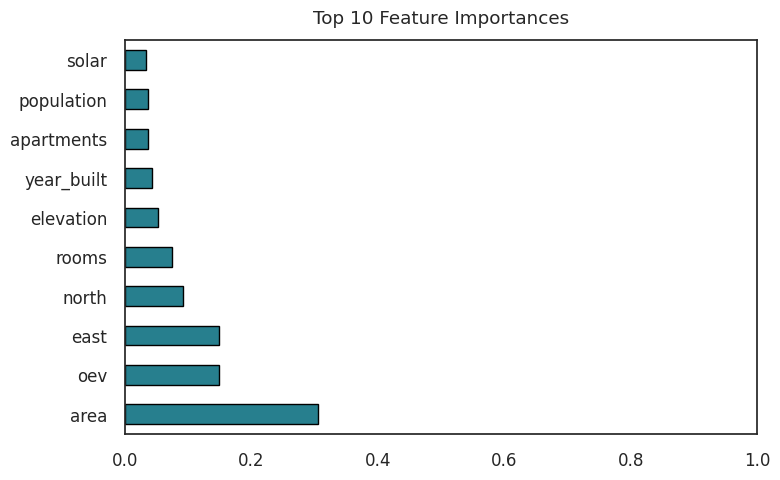

In [169]:
X_data_feature = train.drop(columns=['price'])
y_data_feature = train['price']

model = [XGBRegressor()]

model = [model[i].fit(X_data_feature, y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ':\n',
          model[i].feature_importances_)

    feat_importances = pd.Series(
        model[i].feature_importances_,
        index=X_data_feature.columns
    )

    feat_importances.nlargest(10).plot(
        kind='barh',
        color=COLOR_PRIMARY,     # EIN viridis‑Ton, kein Index
        edgecolor="black"
    )

    plt.xlim(0, 1.0)
    plt.title("Top 10 Feature Importances")
    plt.tight_layout()
    plt.show()


## 4.6 Feature Importance: LightGBM

> ➡️ *Here, we train a LightGBM regression model on the selected features and visualize the top feature importances to evaluate which variables contribute most to the price prediction.*


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000156 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1978
[LightGBM] [Info] Number of data points in the train set: 4535, number of used features: 11
[LightGBM] [Info] Start training from score 1815.761632
LGBMRegresso:
 [508 413 245 461  88 303 137 204 242 362  37]


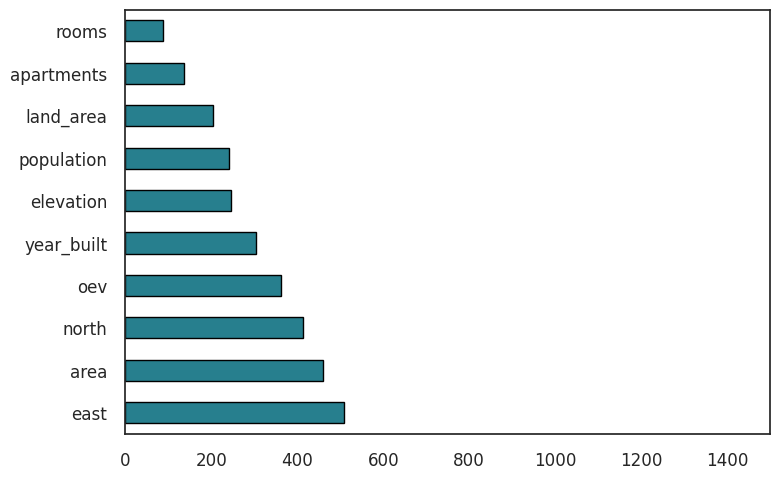

In [168]:
model = [LGBMRegressor()]

model = [model[i].fit(X_data_feature, y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ':\n',
          model[i].feature_importances_)

    feat_importances = pd.Series(
        model[i].feature_importances_,
        index=X_data_feature.columns
    )

    feat_importances.nlargest(10).plot(
        kind='barh',
        color=COLOR_PRIMARY,     # EIN viridis‑Ton, kein Index
        edgecolor="black"
    )

    plt.xlim(0, 1500)
    plt.tight_layout()
    plt.show()


## 4.7 Feature Importance: CatBoost

> ➡️ *Here, we train a CatBoost regression model on the selected features and visualize the top feature importances to assess which variables have the strongest influence on the price prediction.*


CatBoostRegr:
 [25.84986321 11.11569866  3.35672004 28.7392547   4.30500635  5.13945402
  2.66119794  2.88529428  3.27862969 11.61238471  1.0564964 ]


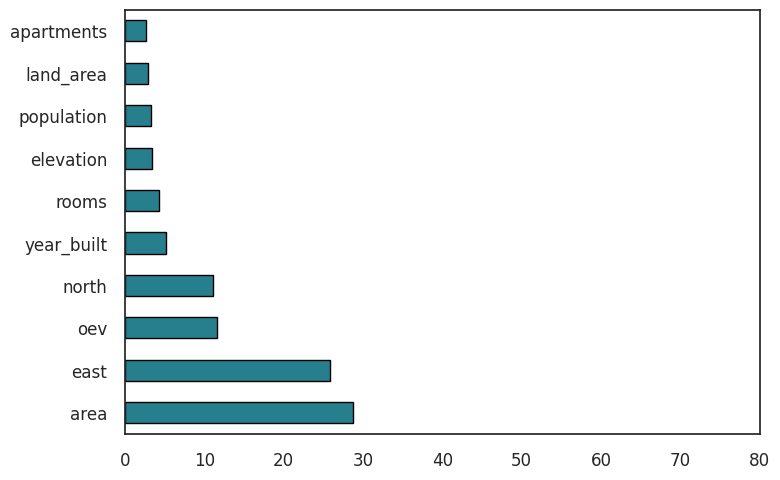

In [167]:
model = [CatBoostRegressor(logging_level='Silent')]

model = [model[i].fit(X_data_feature, y_data_feature) for i in range(len(model))]

num_chr = [12, 12, 10]

for i in range(len(model)):
    print(str(model[i])[:num_chr[i]] + ':\n',
          model[i].feature_importances_)

    feat_importances = pd.Series(
        model[i].feature_importances_,
        index=X_data_feature.columns
    )

    feat_importances.nlargest(10).plot(
        kind='barh',
        color=COLOR_PRIMARY,     # EIN viridis‑Ton, kein Index
        edgecolor="black"
    )

    plt.xlim(0, 80)
    plt.tight_layout()
    plt.show()


## 4.8 Pearson-Korrelation

> ➡️ *Here, we compute the Pearson correlation matrix for all numerical training features and visualize the relationships using a heatmap to identify linear dependencies and potential multicollinearity.*


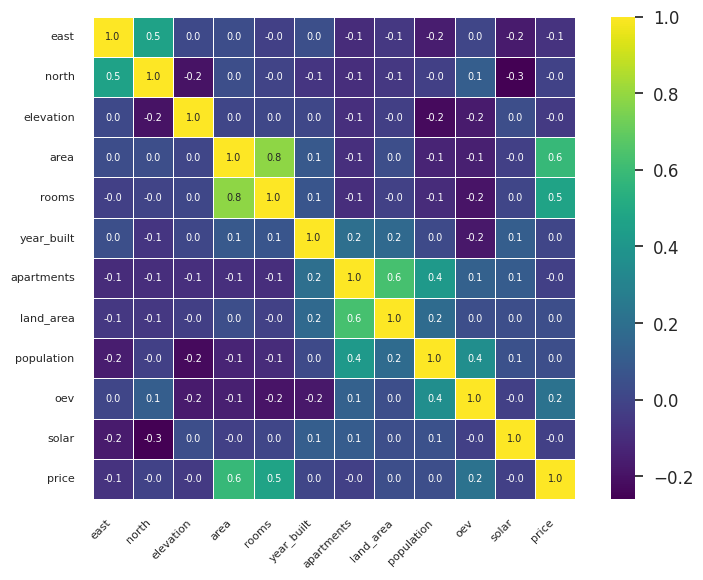

In [166]:
corr = train.corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr,
    cmap="viridis",          # einheitliches Corporate‑Design
    annot=True,
    fmt=".1f",
    annot_kws={"size": 7},
    square=True,
    linewidths=0.5,
    linecolor="white"
)

plt.xticks(rotation=45, ha="right", fontsize=8)
plt.yticks(rotation=0, fontsize=8)

plt.tight_layout()
plt.show()


# 5. Datenvorbereitung für die Modellierung

## 5.1 Feature-Matrix und Zielvariable definieren

> ➡️ *Here, we define the feature matrix by removing the target variable and several high‑correlation or low‑relevance attributes, while keeping the price column as the prediction target.*


In [132]:
drop_cols = [
    "price",
    "solar",
    "elevation",
    "year_built",
    "apartments",
    "east",
    "north"
]

X = train.drop(columns=drop_cols)

y = train["price"]

## 5.2 Preprocessing-Transformatoren importieren

> ➡️ *Here, we import a collection of preprocessing transformers that can be used for scaling, normalization, power transformations, and encoding of numerical and categorical features.*


In [133]:
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler, MaxAbsScaler,QuantileTransformer
from sklearn.preprocessing import PowerTransformer,Normalizer,OrdinalEncoder,FunctionTransformer

## 5.3 Features standardisieren

> ➡️ *Here, we scale the feature matrix using StandardScaler to normalize all numerical variables before model training.*


In [134]:
X_train=X
y_train=y

StandardScaler = StandardScaler()
X_train = StandardScaler.fit_transform(X_train)
X_train = pd.DataFrame(X_train)
X_train

,0,1,2,3,4
0,0.986447,0.180795,0.076128,-0.510040,-0.644737
1,1.361977,-0.728192,0.148779,-0.921803,-0.578360
2,1.174212,1.089783,-0.078488,0.894799,0.271836
3,-0.703440,-0.728192,-0.044957,-1.018689,-0.019673
4,-1.204147,-1.637180,-0.138099,0.349818,-0.150755
...,...,...,...,...,...
4530,0.610917,1.089783,-0.207025,-0.594815,-0.651421
4531,-0.734734,-0.728192,-0.559103,-0.873360,-0.647745
4532,0.078915,-0.728192,-0.294579,-0.364712,-0.532772
4533,1.111624,0.180795,0.146917,-1.115574,-0.522277


## 5.4 Train-Eval-Split

> ➡️ *Here, we split the standardized feature matrix into training and evaluation subsets to validate model performance on unseen data.*


In [135]:
X_train, X_eval, y_train, y_eval = train_test_split(X_train, y_train, test_size=0.2,random_state=2019)
print("Shape of X_train: ",X_train.shape)
print("Shape of X_eval: ", X_eval.shape)
print("Shape of y_train: ",y_train.shape)
print("Shape of y_eval",y_eval.shape)

Shape of X_train:  (3628, 5)
Shape of X_eval:  (907, 5)
Shape of y_train:  (3628,)
Shape of y_eval (907,)


## 5.5 Zielverteilung analysieren

> ➡️ *Here, we visualize the distribution of the target variable in the training set and compute skewness and kurtosis to assess asymmetry and tail behavior.*


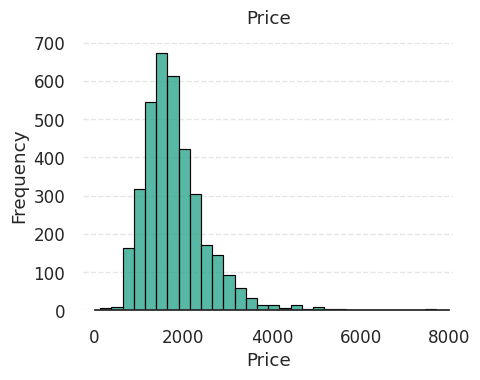

Skewness: 1.731715
Kurtosis: 6.533266


In [162]:
plt.figure(figsize=(5, 4))

sns.histplot(
    y_train,
    bins=30,
    color=sns.color_palette("viridis")[3],   # viridis‑Akzentfarbe
    edgecolor="black"
)

plt.title('Price')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine(trim=True, left=True)

plt.tight_layout()
plt.show()

print("Skewness: %f" % y_train.skew())
print("Kurtosis: %f" % y_train.kurt())


## 5.6 Zielvariable Boxplot

> ➡️ *Here, we visualize the distribution of the target variable using a boxplot to detect outliers and assess the overall spread of price values.*


In [160]:
COLOR_PRIMARY_P = sns.color_palette("viridis")[2]   # dunkler

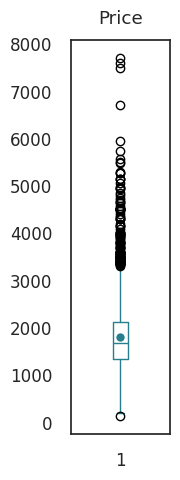

In [161]:
plt.figure(figsize=(2, 5))
plt.boxplot(
    x=y_train,                 # wichtig: x= statt positional
    showmeans=True,
    boxprops=dict(color=COLOR_PRIMARY_P),
    medianprops=dict(color=COLOR_PRIMARY_P),
    whiskerprops=dict(color=COLOR_PRIMARY_P),
    capprops=dict(color=COLOR_PRIMARY_P),
    meanprops=dict(
        marker='o',
        markerfacecolor=COLOR_PRIMARY_P,
        markeredgecolor=COLOR_PRIMARY_P
    )
)
plt.title('Price')
plt.tight_layout()
plt.show()


# 6. Baseline & Benchmarking

> ➡️ *Bevor wir die optimierten Modelle XGBoost und LightGBM trainieren, etablieren wir mehrere einfache Benchmark-Modelle. Diese dienen als Referenzpunkte, gegen die sich die komplexeren Modelle behaupten müssen.*

**Warum brauchen wir Benchmarks?**

- **Naive Baseline (DummyRegressor mit Median):** Diese Baseline sagt für jede Wohnung dieselbe Miete – nämlich den Median der Trainingsmieten – vorher. Sie zeigt, welches Performance-Niveau ein Modell *mindestens* schlagen muss, um überhaupt nützlich zu sein. Ein R² ≈ 0 bedeutet hier per Definition: keinerlei Lerngewinn gegenüber dem trivialen Median.
- **Linear Regression:** Ein einfacher, vollständig interpretierbarer linearer Benchmark. Falls die Beziehung zwischen Features und Miete bereits gut linear approximierbar ist, sollte dieses Modell deutlich besser abschneiden als die naive Baseline. Es liefert uns ein Gefühl dafür, wie viel der Varianz schon mit linearen Annahmen erklärbar ist. Da die Features bereits skaliert vorliegen, wird hier keine zusätzliche Skalierung mehr durchgeführt.
- **Random Forest Regressor:** Ein nicht-linearer, ensemble-basierter Benchmark. Random Forests fangen Interaktionen und nichtlineare Effekte zwischen Features ohne explizites Feature Engineering ein. Damit zeigen sie, ob in den Daten überhaupt nichtlineare Strukturen vorhanden sind, die XGBoost und LightGBM ausnutzen können.

Alle Modelle werden auf denselben bereits vorbereiteten Splits (`X_train`, `X_eval`, `y_train`, `y_eval`) trainiert und mit denselben Metriken bewertet wie die späteren XGBoost-/LightGBM-Modelle.

In [138]:
# === Baseline & Benchmarking ===
# Verwendet die bereits vorhandenen Splits X_train, X_eval, y_train, y_eval.
# Es wird KEIN neuer Train-Test-Split erzeugt und KEINE Skalierung wiederholt.

import numpy as np
import pandas as pd

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import cross_val_score


def evaluate_benchmark(model, name, X_tr, y_tr, X_ev, y_ev, cv=5):
    """Trainiert ein Modell und berechnet MAE, RMSE, R2 (eval) sowie 5-fold CV-R2."""
    model.fit(X_tr, y_tr)
    y_pred_ev = model.predict(X_ev)

    mae   = mean_absolute_error(y_ev, y_pred_ev)
    rmse  = np.sqrt(mean_squared_error(y_ev, y_pred_ev))
    r2    = r2_score(y_ev, y_pred_ev)
    cv_r2 = cross_val_score(model, X_tr, y_tr, cv=cv, scoring='r2').mean()
    # MedAE wird hier als sqrt(median_absolute_error) berechnet,
    # damit die Werte mit der bestehenden predict-Tabelle (XGB/LGBM) vergleichbar bleiben.
    medae = np.sqrt(median_absolute_error(y_ev, y_pred_ev))

    return {
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2_Score(eval)': r2,
        'Cross-Validation': cv_r2,
        'MedAE': medae,
    }


# 1) Naive Baseline – sagt immer den Median der Trainings-Miete vorher
dummy_model = DummyRegressor(strategy='median')

# 2) Linear Regression – einfacher linearer Benchmark
#    Features sind bereits skaliert -> keine zusätzliche Skalierung
linreg_model = LinearRegression()

# 3) Random Forest Regressor – nicht-linearer Benchmark
rf_bench_model = RandomForestRegressor(
    n_estimators=300,
    random_state=2019,
    n_jobs=-1,
    min_samples_leaf=2,
)

benchmark_models = [
    (dummy_model,    'DummyRegressor (median)'),
    (linreg_model,   'LinearRegression'),
    (rf_bench_model, 'RandomForest'),
]

benchmark_raw = [
    evaluate_benchmark(m, n, X_train, y_train, X_eval, y_eval)
    for m, n in benchmark_models
]

# Übersichtstabelle (sortiert nach R2 absteigend)
benchmark_results = (
    pd.DataFrame(benchmark_raw)[
        ['Model', 'MAE', 'RMSE', 'R2_Score(eval)', 'Cross-Validation']
    ]
    .sort_values(by='R2_Score(eval)', ascending=False)
    .reset_index(drop=True)
)

# Optionale Vergleichstabelle, kompatibel zur späteren `predict`-Tabelle
# der XGBoost-/LightGBM-Modelle (gleiche Spaltenstruktur:
# Model, MedAE, R2_Score(eval), Cross-Validation),
# damit sie sich später per pd.concat([predict, benchmark_predict])
# zusammenführen lassen.
benchmark_predict = (
    pd.DataFrame(benchmark_raw)[
        ['Model', 'MedAE', 'R2_Score(eval)', 'Cross-Validation']
    ]
    .reset_index(drop=True)
)

print('Benchmark-Resultate (sortiert nach R2 auf X_eval):')
display(benchmark_results)

print('\nVergleichstabelle benchmark_predict (kompatibel zu `predict`):')
display(benchmark_predict)

Benchmark-Resultate (sortiert nach R2 auf X_eval):


,Model,MAE,RMSE,R2_Score(eval),Cross-Validation
0,RandomForest,347.918048,512.784887,0.530962,0.491452
1,LinearRegression,394.435658,552.785669,0.454931,0.429478
2,DummyRegressor (median),535.594267,771.109948,-0.060646,-0.032127



Vergleichstabelle benchmark_predict (kompatibel zu `predict`):


,Model,MedAE,R2_Score(eval),Cross-Validation
0,DummyRegressor (median),19.364917,-0.060646,-0.032127
1,LinearRegression,17.096309,0.454931,0.429478
2,RandomForest,15.504949,0.530962,0.491452


### Interpretation der Benchmark-Resultate

- **DummyRegressor (median):** Liefert per Definition ein R² nahe 0 auf den Evaluationsdaten und ein negatives oder nahe-null CV-R². Die zugehörigen MAE/RMSE-Werte zeigen, wie groß der durchschnittliche Fehler wäre, wenn wir gar nichts modellieren würden – das ist die Untergrenze, die jedes ernstzunehmende Modell schlagen muss.
- **LinearRegression:** Sollte deutlich über dem DummyRegressor liegen, sofern die linearen Zusammenhänge zwischen den Features (z. B. Wohnfläche, Zimmerzahl, Lage) und der Miete substanziell sind. Die Lücke zwischen Linear Regression und Random Forest gibt einen Hinweis auf den Anteil **nichtlinearer Information** in den Daten.
- **RandomForest:** Ist als nicht-linearer Benchmark in der Regel das stärkste der drei einfachen Modelle. Wenn XGBoost bzw. LightGBM später nicht klar besser abschneiden als der Random Forest, lohnt sich die zusätzliche Tuning-Komplexität nicht oder die Hyperparameter sind noch nicht ausreichend optimiert.

**Was wir in den nächsten Abschnitten erwarten:**

> Ein gut getuntes XGBoost- bzw. LightGBM-Modell sollte auf `X_eval` ein höheres R² und einen niedrigeren MAE/RMSE erreichen als der RandomForest-Benchmark. Die gleiche Reihenfolge sollte sich auch im 5-fold-Cross-Validation-Score widerspiegeln, damit wir Overfitting auf den Eval-Split ausschließen können.

Die Variable `benchmark_results` hält die ausführliche Bewertung mit MAE, RMSE, R²(eval) und CV-R². `benchmark_predict` ist bewusst spaltenkompatibel zur bestehenden `predict`-Tabelle aufgebaut, sodass die Benchmark-Modelle später mit `predict_combined = pd.concat([predict, benchmark_predict], ignore_index=True)` gemeinsam visualisiert werden können.

# 7. Optimierte Boosting-Modelle

> ➡️ *Mit der Baseline im Rücken wechseln wir nun auf die Boosting-Welt. Die folgenden Hyperparameter stammen aus einer separaten Tuning-Phase (Optuna) und werden hier direkt eingesetzt – wir reproduzieren die Suche nicht, sondern verwenden die besten Resultate.*

## 7.1 XGBoost Hyperparameter


In [139]:
params_XGB_best ={'n_estimators': 2565,
 'learning_rate': 0.09732287808197748,
 'max_depth': 6,
 'min_child_weight': 0.007737991528812258,
 'subsample': 0.1,
 'colsample_bytree': 1.0,
 'colsample_bylevel': 0.9,
 'gamma': 1.3007598689577686,
 'reg_lambda': 9.683728618282095e-06,
 'reg_alpha': 0.08617584406570492}

## 7.2 LightGBM Hyperparameter

> ➡️ *Here, we define the optimized LightGBM hyperparameters obtained from the tuning process to configure the final model setup.*


In [140]:
params_LGBM_best ={'n_estimators': 2309,
 'learning_rate': 0.04942932762026841,
 'max_depth': 6,
 'min_child_weight': 0.21030657642741743,
 'subsample': 0.30000000000000004,
 'colsample_bytree': 0.775,
 'reg_lambda': 0.21539132638034386,
 'reg_alpha': 2.5398950960373498e-08}

## 7.3 Modelle trainieren

> ➡️ *Here, we train the final XGBoost and LightGBM models using the optimized hyperparameters and fit them on the standardized training data.*


In [141]:
XGBRegressor_model = xgb.XGBRegressor(**params_XGB_best,objective='reg:absoluteerror').fit(X_train,y_train)
LGBM_model = lgbm.LGBMRegressor(**params_LGBM_best,objective='regression_l1').fit(X_train,y_train)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000096 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 928
[LightGBM] [Info] Number of data points in the train set: 3628, number of used features: 5
[LightGBM] [Info] Start training from score 1675.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

## 7.4 Cross-Validation & Eval-Metriken

> ➡️ *Here, we evaluate both models using cross‑validation on the training set and compute R² and Median Absolute Error on the evaluation split to compare their predictive performance.*


In [142]:
cv_XGBoost = cross_val_score(estimator = XGBRegressor_model, X = X_train, y = y_train, cv = 5)
y_pred_XGBoost_eval = XGBRegressor_model.predict(X_eval)
r2_score_XGBoost_eval = r2_score(y_eval, y_pred_XGBoost_eval)
MedAE_XGBoost = (np.sqrt(median_absolute_error(y_eval, y_pred_XGBoost_eval)))
print("CV: ", cv_XGBoost.mean())
print('R2_score (eval): ', r2_score_XGBoost_eval)
print("MedAE: ", MedAE_XGBoost)

cv_LGBM = cross_val_score(estimator = LGBM_model, X = X_train, y = y_train, cv = 5)
y_pred_LGBM_eval = LGBM_model.predict(X_eval)
r2_score_LGBM_eval = r2_score(y_eval, y_pred_LGBM_eval)
MedAE_LGBM = (np.sqrt(median_absolute_error(y_eval, y_pred_LGBM_eval)))
print("CV: ", cv_LGBM.mean())
print('R2_score (eval): ', r2_score_LGBM_eval)
print("MedAE: ", MedAE_LGBM)

CV:  0.32912594079971313
R2_score (eval):  0.3325788974761963
MedAE:  16.802767861650057
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 926
[LightGBM] [Info] Number of data points in the train set: 2902, number of used features: 5
[LightGBM] [Info] Start training from score 1675.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with 

# 8. Modellvergleich – alle 5 Modelle

## 8.1 Vergleichstabelle

> ➡️ *Hier konsolidieren wir die Evaluationsmetriken **aller fünf Modelle** – die beiden optimierten Boosting-Modelle (XGBoost, LightGBM) und die drei Benchmark-Modelle (DummyRegressor, LinearRegression, RandomForest) – in einer gemeinsamen Vergleichstabelle. So sehen wir auf einen Blick, ob und wie deutlich die getunten Modelle die einfacheren Referenzen schlagen.*

**Lesehilfe für die Tabelle:**

- **MedAE:** Wurzel des Medians des absoluten Fehlers (kleiner = besser). Robust gegenüber Ausreißern.
- **R2_Score(eval):** Anteil der erklärten Varianz auf dem Eval-Split. 0 = so gut wie der Median-Dummy, 1 = perfekt.
- **Cross-Validation:** Durchschnittliches R² über 5 Folds auf den Trainingsdaten – misst Stabilität / Generalisierung.


In [143]:
models = [('XGB', MedAE_XGBoost,  r2_score_XGBoost_eval, cv_XGBoost.mean()),
        ( 'LGBM', MedAE_LGBM, r2_score_LGBM_eval, cv_LGBM.mean())
         ]


predict = pd.DataFrame(data = models, columns=['Model', 'MedAE', 'R2_Score(eval)', 'Cross-Validation'])

# Benchmark-Modelle (DummyRegressor, LinearRegression, RandomForest)
# an die predict-Tabelle anhängen, damit alle 5 Modelle gemeinsam verglichen werden.
predict = pd.concat([predict, benchmark_predict], ignore_index=True)

predict

,Model,MedAE,R2_Score(eval),Cross-Validation
0,XGB,16.802768,0.332579,0.329126
1,LGBM,15.555719,0.510206,0.473619
2,DummyRegressor (median),19.364917,-0.060646,-0.032127
3,LinearRegression,17.096309,0.454931,0.429478
4,RandomForest,15.504949,0.530962,0.491452


## 8.2 Visualisierung MedAE

> ➡️ *Wir visualisieren den Median Absolute Error für alle fünf Modelle. Je kürzer der Balken, desto präziser die Vorhersage. Der DummyRegressor markiert hier die obere Schmerzgrenze – jedes ernstzunehmende Modell muss deutlich darunter liegen.*


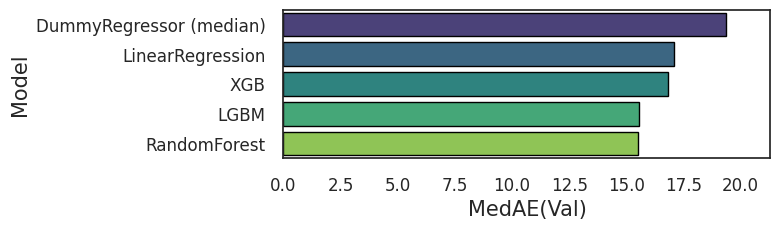

In [152]:
# Sortieren
predict.sort_values(by=['MedAE'], ascending=False, inplace=True)

# Viridis‑Gradient passend zur Anzahl der Modelle
colors = sns.color_palette("viridis", len(predict))

f, axe = plt.subplots(1, 1, figsize=(8, 2.5))

sns.barplot(
    x='MedAE',
    y='Model',
    data=predict,
    ax=axe,
    palette=colors,
    edgecolor="black"
)

axe.set_xlabel('MedAE(Val)', size=15)
axe.set_ylabel('Model', size=15)

# Auto‑Skalierung, damit auch große Fehler sichtbar bleiben
axe.set_xlim(0, predict['MedAE'].max() * 1.1)

plt.tight_layout()
plt.show()


## 8.3 Visualisierung R²-Score

> ➡️ *R² zeigt, wie viel der Mietpreis-Varianz ein Modell erklären kann. Der DummyRegressor liegt definitionsgemäß bei ≈ 0; die Lücke zwischen LinearRegression und RandomForest deutet auf nichtlineare Information hin, die XGBoost und LightGBM idealerweise noch besser ausschöpfen sollten.*


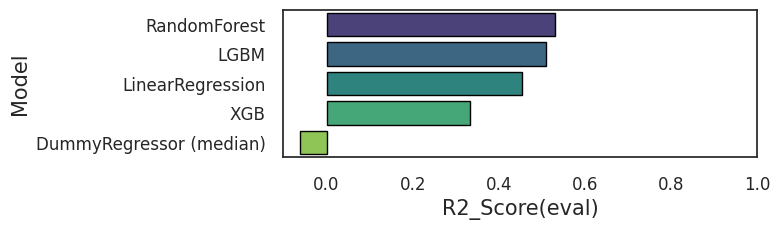

In [151]:
# Sortieren
predict.sort_values(by=['R2_Score(eval)'], ascending=False, inplace=True)

# Viridis‑Gradient für die Anzahl der Modelle
colors = sns.color_palette("viridis", len(predict))

f, axe = plt.subplots(1, 1, figsize=(8, 2.5))

sns.barplot(
    x='R2_Score(eval)',
    y='Model',
    data=predict,
    ax=axe,
    palette=colors,
    edgecolor="black"
)

axe.set_xlabel('R2_Score(eval)', size=15)
axe.set_ylabel('Model', size=15)

# Untere Grenze leicht negativ, damit auch DummyRegressor sichtbar bleibt
axe.set_xlim(min(-0.1, predict['R2_Score(eval)'].min() * 1.1), 1.0)

plt.tight_layout()
plt.show()


## 8.4 Visualisierung Cross-Validation

> ➡️ *5-fold-Cross-Validation auf den Trainingsdaten – ein Stabilitätstest. Wenn das CV-R² eines Modells deutlich unter dem Eval-R² liegt, deutet das auf Overfitting auf den Eval-Split hin. Idealerweise ist die Reihenfolge der Modelle hier dieselbe wie im Eval-R²-Plot.*


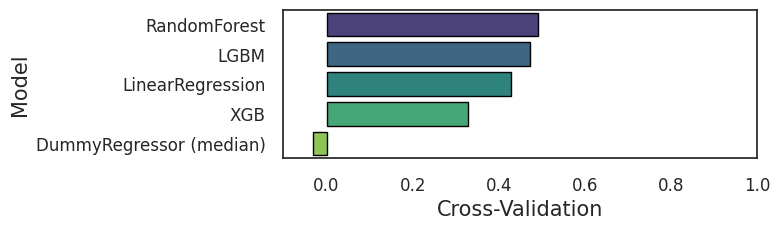

In [154]:
# Sortieren
predict.sort_values(by=['Cross-Validation'], ascending=False, inplace=True)

# Viridis‑Gradient passend zur Anzahl der Modelle
colors = sns.color_palette("viridis", len(predict))

f, axe = plt.subplots(1, 1, figsize=(8, 2.5))

sns.barplot(
    x='Cross-Validation',
    y='Model',
    data=predict,
    ax=axe,
    palette=colors,
    edgecolor="black"
)

axe.set_xlabel('Cross-Validation', size=15)
axe.set_ylabel('Model', size=15)

# Untere Grenze leicht negativ, damit auch DummyRegressor sichtbar bleibt
axe.set_xlim(min(-0.1, predict['Cross-Validation'].min() * 1.1), 1.0)

plt.tight_layout()
plt.show()


## 8.5 Zwischenfazit der Modellbewertung

> ➡️ *Bevor wir mit den Test-Predictions weitermachen, halten wir kurz inne und ordnen die fünf Modelle entlang der bisherigen Storyline ein.*

**Was haben wir gesehen?**

1. **DummyRegressor (median)** liefert die Untergrenze. Sein R² liegt definitionsgemäß bei ≈ 0 – jeder Lerngewinn bei den anderen Modellen ist also tatsächlich auf gelernte Struktur in den Features zurückzuführen, nicht auf Zufall.
2. **LinearRegression** zeigt, wie viel der Mietpreis-Varianz schon durch rein lineare Zusammenhänge erklärbar ist. Liegt sie deutlich über dem Dummy, sind die Features grundsätzlich informativ.
3. **RandomForest** fängt zusätzlich nichtlineare Effekte und Feature-Interaktionen ein. Die Differenz zur LinearRegression quantifiziert den Nutzen nichtlinearer Modellierung.
4. **XGBoost / LightGBM** sollten als getunte Boosting-Modelle die Spitze bilden. Tun sie das nicht klar, lohnt sich entweder weiteres Hyperparameter-Tuning oder ein kritischer Blick auf das Feature Engineering.

**Was zählt für die nächsten Schritte?**

Für die finale Vorhersage auf dem Test-Set verwenden wir die optimierten Boosting-Modelle. Die Benchmarks bleiben aber als Referenz erhalten – sie machen die Verbesserung quantifizierbar und schützen davor, ein komplexes Modell zu bauen, das gegenüber einer einfachen Baseline kaum Mehrwert liefert.

# 9. Test-Predictions

## 9.1 Test-Datensatz vorbereiten

> ➡️ *Here, we prepare the test dataset by resetting the index and removing the same non‑feature columns that were excluded from the training data to ensure consistent preprocessing.*


In [147]:
import_test0 = test.reset_index(drop=True)

import_test = import_test0.drop(
    columns=[
        'price',
        'solar_class',
        'elevation',
        'year_built',
        'number_of_apartments',
        'total_floor_area',
        'lv95_east',
        'lv95_north'
    ],
    errors='ignore'
)

import_test

,east,north,area,rooms,apartments,land_area,population,oev,solar
0,2539103.75,1152548.250,57,2,20,420.0,186,10892.0,3.0
1,2655301.50,1222483.375,48,2,5,409.0,58,73.0,3.0
2,2604730.00,1129117.875,70,2,16,297.0,29,126.0,4.0
3,2638795.25,1266197.000,94,3,9,267.0,144,3537.0,4.0
4,2613913.50,1210679.250,84,3,8,292.0,93,4172.0,4.0
...,...,...,...,...,...,...,...,...,...
903,2697976.50,1122567.375,54,2,2,105.0,37,297.0,4.0
904,2681588.00,1253222.125,80,2,6,247.0,79,2017.0,3.0
905,2605452.50,1210915.875,113,3,8,484.0,17,2174.0,1.0
906,2609938.75,1224044.250,90,3,8,312.0,81,5234.0,4.0


## 9.2 Trainings-Feature-Matrix vorbereiten

> ➡️ *Here, we reset the index of the training feature matrix to ensure a clean, continuous index before applying further preprocessing or merging operations.*


In [148]:
import_train = X.reset_index(drop=True)
import_train

,area,rooms,land_area,population,oev
0,109,3,446.0,67,342.0
1,121,2,485.0,33,1335.0
2,115,4,363.0,183,14054.0
3,55,2,381.0,25,9693.0
4,39,1,331.0,138,7732.0
...,...,...,...,...,...
4530,97,4,294.0,60,242.0
4531,54,2,105.0,37,297.0
4532,80,2,247.0,79,2017.0
4533,113,3,484.0,17,2174.0


## 9.3 Skalierung Train + Test

> ➡️ *Here, we concatenate the training and test feature matrices to apply a consistent StandardScaler transformation across both datasets, and then extract the scaled test portion for final prediction.*


In [149]:
Row_Number = len(import_test)

X_test_target1_df = pd.concat([import_train, import_test], ignore_index=True)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_test_target1_scaled = scaler.fit_transform(X_test_target1_df)

test_pred_target0 = pd.DataFrame(
    X_test_target1_scaled,
    columns=X_test_target1_df.columns
).tail(Row_Number)

test_pred_target0

,area,rooms,land_area,population,oev,east,north,apartments,solar
4535,-0.644121,-0.741164,0.022991,0.918186,0.057047,-1.401520,-1.208310,0.165303,-0.084370
4536,-0.925212,-0.741164,0.002634,-0.620629,-0.666065,0.257295,0.101386,-0.457153,-0.084370
4537,-0.238101,-0.741164,-0.204643,-0.969266,-0.662523,-0.464653,-1.647097,-0.000686,0.897783
4538,0.511474,0.170922,-0.260163,0.413262,-0.434541,0.021655,0.920025,-0.291165,0.897783
4539,0.199151,0.170922,-0.213896,-0.199859,-0.392099,-0.333552,-0.119673,-0.332662,0.897783
...,...,...,...,...,...,...,...,...,...
5438,-0.737818,-0.741164,-0.559973,-0.873090,-0.651093,0.866515,-1.769770,-0.581644,0.897783
5439,0.074222,-0.741164,-0.297177,-0.368167,-0.536133,0.632556,0.677040,-0.415656,-0.084370
5440,1.104888,0.170922,0.141435,-1.113530,-0.525640,-0.454339,-0.115242,-0.332662,-2.048675
5441,0.386545,0.170922,-0.176882,-0.344123,-0.321118,-0.390294,0.130617,-0.332662,0.897783


## 9.4 Skalierte Test-Features finalisieren

> ➡️ *Here, we reset the index of the scaled test feature matrix to ensure a clean, continuous index before generating predictions.*


In [150]:
test_pred_target0 = test_pred_target0.reset_index(drop=True)
test_pred_target0

,area,rooms,land_area,population,oev,east,north,apartments,solar
0,-0.644121,-0.741164,0.022991,0.918186,0.057047,-1.401520,-1.208310,0.165303,-0.084370
1,-0.925212,-0.741164,0.002634,-0.620629,-0.666065,0.257295,0.101386,-0.457153,-0.084370
2,-0.238101,-0.741164,-0.204643,-0.969266,-0.662523,-0.464653,-1.647097,-0.000686,0.897783
3,0.511474,0.170922,-0.260163,0.413262,-0.434541,0.021655,0.920025,-0.291165,0.897783
4,0.199151,0.170922,-0.213896,-0.199859,-0.392099,-0.333552,-0.119673,-0.332662,0.897783
...,...,...,...,...,...,...,...,...,...
903,-0.737818,-0.741164,-0.559973,-0.873090,-0.651093,0.866515,-1.769770,-0.581644,0.897783
904,0.074222,-0.741164,-0.297177,-0.368167,-0.536133,0.632556,0.677040,-0.415656,-0.084370
905,1.104888,0.170922,0.141435,-1.113530,-0.525640,-0.454339,-0.115242,-0.332662,-2.048675
906,0.386545,0.170922,-0.176882,-0.344123,-0.321118,-0.390294,0.130617,-0.332662,0.897783
